# HMM市场状态预测

## 分钟频次的市场状态预测

# 1.数据准备

## 1.1 观察数据

In [1]:
#导包
import pandas as pd
import numpy as np
from hmmlearn import hmm
import joblib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import mode

In [2]:
df_min = pd.read_csv('../data/symbo1hf_slope_data.csv')
df_min.set_index('DateTime', inplace=True)
df_min

,Unnamed: 0,open,high,low,close,vol,amount,trade_count,SetDay,time_start,...,139,140,141,142,143,144,145,146,147,fut_vwap
DateTime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0,129.12,132.96,126.79,127.45,851723.990,1.108898e+08,73481.0,2020-01-01,0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,127.222166
2020-01-02 17:00:00,1,127.45,127.60,126.25,127.43,64402.967,8.169874e+06,6531.0,2020-01-02,1,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,127.322573
2020-01-02 17:48:00,2,127.40,128.50,125.78,128.21,170011.680,2.160107e+07,17382.0,2020-01-02,2,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,129.024238
2020-01-03 04:43:00,3,128.18,130.18,128.15,128.93,100001.663,1.292580e+07,8996.0,2020-01-03,3,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,128.953444
2020-01-03 05:42:00,4,128.93,131.76,128.66,131.60,114236.728,1.480768e+07,11262.0,2020-01-03,4,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,132.457900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-26 18:34:00,22676,3029.40,3070.00,3002.00,3044.54,1345393.629,4.080718e+09,2179217.0,2025-11-26,22676,...,NaN,1.233502,1.233408,-0.548092,-0.601091,2.029145,2.264071,2.759046,-0.806173,3041.321231
2025-11-27 03:30:00,22677,3044.53,3052.73,3015.26,3038.71,632036.468,1.915628e+09,976000.0,2025-11-27,22677,...,NaN,1.183820,1.183729,-0.518713,-0.559118,1.889697,2.214630,2.734603,-0.771614,3039.016053
2025-11-27 09:33:00,22678,3038.71,3044.00,3000.00,3000.97,405121.230,1.224257e+09,490769.0,2025-11-27,22678,...,NaN,1.074328,1.074242,-0.490825,-0.513085,1.754915,2.173197,2.704478,-0.733987,2996.364919


## 1.2 特征工程

选择5个特征

In [3]:
# im_model
# 一日对数成交量差
df_min['vol_log_ret_1p'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(1))

# 五日对数成交量差
df_min['vol_log_ret_5p'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(5))

# 一日对数收盘价差 (当日收益率)
df_min['close_log_ret_1p'] = np.log(df_min['close']) - np.log(df_min['close'].shift(1))

# 五日对数收盘价差 (五日动量)
df_min['close_log_ret_5p'] = np.log(df_min['close']) - np.log(df_min['close'].shift(5))

# 当日对数高低价差 (当日内波动)
df_min['intraday_range_log'] = np.log(df_min['high']) - np.log(df_min['low'])
# 删除前五行数据（滑窗）
df_min = df_min.drop(df_min.index[:5])
df_min.index = pd.to_datetime(df_min.index)
df_min[:15]

,Unnamed: 0,open,high,low,close,vol,amount,trade_count,SetDay,time_start,...,144,145,146,147,fut_vwap,vol_log_ret_1p,vol_log_ret_5p,close_log_ret_1p,close_log_ret_5p,intraday_range_log
DateTime,,,,,,,,,,,,,,,,,,,,,
2020-01-03 08:42:00,5,131.60,132.97,130.86,131.92,83934.170,1.109403e+07,10675.0,2020-01-03,5,...,0.0,0.0,0.0,0.0,131.891542,-0.308240,-2.317230,0.002429,0.034472,0.015995
2020-01-03 09:38:00,6,131.92,133.95,130.94,131.75,201275.461,2.661306e+07,23611.0,2020-01-03,6,...,0.0,0.0,0.0,0.0,131.732520,0.874642,1.139515,-0.001289,0.033339,0.022727
2020-01-03 14:54:00,7,131.75,132.30,131.57,132.25,21076.713,2.778291e+06,2595.0,2020-01-03,7,...,0.0,0.0,0.0,0.0,132.344469,-2.256506,-2.087698,0.003788,0.031025,0.005533
2020-01-03 15:58:00,8,132.23,134.94,131.92,132.32,277986.604,3.703987e+07,33235.0,2020-01-03,8,...,0.0,0.0,0.0,0.0,132.279456,2.579404,1.022386,0.000529,0.025954,0.022635
2020-01-03 22:30:00,9,132.31,132.95,132.15,132.93,4412.132,5.845631e+05,592.0,2020-01-03,9,...,0.0,0.0,0.0,0.0,133.115010,-4.143215,-3.253915,0.004599,0.010056,0.006035
2020-01-03 22:55:00,10,132.94,135.80,132.41,133.70,449082.088,6.005435e+07,56708.0,2020-01-03,10,...,0.0,0.0,0.0,0.0,133.115894,4.622848,1.677173,0.005776,0.013403,0.025280
2020-01-04 18:50:00,11,133.72,135.22,132.70,134.93,144254.493,1.931806e+07,18473.0,2020-01-04,11,...,0.0,0.0,0.0,0.0,135.018688,-1.135627,-0.333095,0.009158,0.023850,0.018812
2020-01-05 00:55:00,12,134.97,138.17,134.63,136.69,507195.554,6.914431e+07,54116.0,2020-01-05,12,...,0.0,0.0,0.0,0.0,136.140238,1.257318,3.180728,0.012959,0.033022,0.025955
2020-01-05 21:31:00,13,136.69,136.73,134.16,135.16,134625.931,1.820613e+07,13486.0,2020-01-05,13,...,0.0,0.0,0.0,0.0,135.214083,-1.326397,-0.725073,-0.011256,0.021236,0.018975


In [4]:
# symbolhf数据
# 一日对数成交量差
df_min['vol_log_ret_1p'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(1))

# 五日对数成交量差
df_min['vol_log_ret_5p'] = np.log(df_min['vol']) - np.log(df_min['vol'].shift(5))

# 一日对数收盘价差 (当日收益率)
df_min['close_log_ret_1p'] = np.log(df_min['close']) - np.log(df_min['close'].shift(1))

# 五日对数收盘价差 (五日动量)
df_min['close_log_ret_5p'] = np.log(df_min['close']) - np.log(df_min['close'].shift(5))

# 当日对数高低价差 (当日内波动)
df_min['intraday_range_log'] = np.log(df_min['high']) - np.log(df_min['low'])
# 删除前五行数据（滑窗）
df_min['pct'] = ((df_min['fut_vwap'] - df_min['fut_vwap'].shift(1))/df_min['fut_vwap'].shift(1)).shift(-1)
df_min = df_min.drop(df_min.index[:5])
df_min.index = pd.to_datetime(df_min.index)
df_min[:15]

,Unnamed: 0,open,high,low,close,vol,amount,trade_count,SetDay,time_start,...,145,146,147,fut_vwap,vol_log_ret_1p,vol_log_ret_5p,close_log_ret_1p,close_log_ret_5p,intraday_range_log,pct
DateTime,,,,,,,,,,,,,,,,,,,,,
2020-01-03 22:55:00,10,132.94,135.80,132.41,133.70,449082.088,6.005435e+07,56708.0,2020-01-03,10,...,0.0,0.0,0.0,133.115894,4.622848,1.677173,0.005776,0.013403,0.025280,0.014294
2020-01-04 18:50:00,11,133.72,135.22,132.70,134.93,144254.493,1.931806e+07,18473.0,2020-01-04,11,...,0.0,0.0,0.0,135.018688,-1.135627,-0.333095,0.009158,0.023850,0.018812,0.008307
2020-01-05 00:55:00,12,134.97,138.17,134.63,136.69,507195.554,6.914431e+07,54116.0,2020-01-05,12,...,0.0,0.0,0.0,136.140238,1.257318,3.180728,0.012959,0.033022,0.025955,-0.006803
2020-01-05 21:31:00,13,136.69,136.73,134.16,135.16,134625.931,1.820613e+07,13486.0,2020-01-05,13,...,0.0,0.0,0.0,135.214083,-1.326397,-0.725073,-0.011256,0.021236,0.018975,0.022362
2020-01-06 00:11:00,14,135.16,137.69,134.82,137.59,68332.122,9.296019e+06,6639.0,2020-01-06,14,...,0.0,0.0,0.0,138.237678,-0.678120,2.740022,0.017819,0.034456,0.021064,0.005364
2020-01-06 02:04:00,15,137.59,139.62,137.46,138.69,110747.251,1.536163e+07,10539.0,2020-01-06,15,...,0.0,0.0,0.0,138.979220,0.482871,-1.399955,0.007963,0.036643,0.015591,0.007710
2020-01-06 03:04:00,16,138.65,143.00,138.17,141.02,437444.007,6.152745e+07,33733.0,2020-01-06,16,...,0.0,0.0,0.0,140.050788,1.373698,1.109370,0.016660,0.044146,0.034360,0.008063
2020-01-06 13:55:00,17,141.05,141.42,139.02,141.16,97498.556,1.369232e+07,8316.0,2020-01-06,17,...,0.0,0.0,0.0,141.179963,-1.501111,-1.649059,0.000992,0.032178,0.017116,0.009819
2020-01-06 14:55:00,18,141.18,145.25,139.97,142.55,542993.843,7.748342e+07,45961.0,2020-01-06,18,...,0.0,0.0,0.0,142.566144,1.717260,1.394598,0.009799,0.053234,0.037028,0.002630


## 1.3 特征标准化

### 1.3.1 正常训练--测试

In [5]:

window = 336
features = ['vol_log_ret_1p','vol_log_ret_5p','close_log_ret_1p','close_log_ret_5p','intraday_range_log']
# 计算滚动均值和滚动标准差
rolling_mean = df_min[features].rolling(window=window).mean()
rolling_std = df_min[features].rolling(window=window).std()


# 执行滚动标准化
# 前 251 行会因为窗口不足产生 NaN
df_feature_rolling = (df_min[features] - rolling_mean) / rolling_std
df_train_norm = df_feature_rolling.loc[:'2023-12-30'].dropna()
df_test_norm = df_feature_rolling.loc['2024-01-01':]
X_train = df_train_norm
X_test = df_test_norm


### 1.3.2 交叉验证

In [6]:
# import pandas as pd

# # 设定窗口
# window = 336
# features = ['vol_log_ret_1p','vol_log_ret_5p','close_log_ret_1p','close_log_ret_5p','intraday_range_log','successive_increase_count','successive_decrease_count']

# # 定义两个时间段
# period_A_start, period_A_end = '2022-07-22 09:30', '2024-09-30 15:00'
# period_B_start, period_B_end = '2024-10-01 09:30', '2026-3-20 14:45'

# # 如果你想用 Period B 训练，Period A 测试：
# train_raw = df_min.loc[period_B_start : period_B_end]
# test_raw = df_min.loc[period_A_start : period_A_end]

# def get_norm_data(df, features, window):
#     # 局部计算滚动指标，避免利用另一段数据的信息
#     rolling_mean = df[features].rolling(window=window).mean()
#     rolling_std = df[features].rolling(window=window).std()
#     return ((df[features] - rolling_mean) / rolling_std).dropna()

# X_train = get_norm_data(train_raw, features, window)
# X_test = get_norm_data(test_raw, features, window)

In [7]:
X_train.index

DatetimeIndex(['2020-02-10 05:58:00', '2020-02-10 06:23:00',
               '2020-02-10 09:23:00', '2020-02-10 09:47:00',
               '2020-02-10 13:04:00', '2020-02-10 14:03:00',
               '2020-02-10 14:45:00', '2020-02-10 16:07:00',
               '2020-02-10 20:39:00', '2020-02-10 21:50:00',
               ...
               '2023-12-28 13:01:00', '2023-12-28 13:23:00',
               '2023-12-28 14:45:00', '2023-12-28 16:08:00',
               '2023-12-29 01:37:00', '2023-12-29 02:00:00',
               '2023-12-29 15:42:00', '2023-12-29 17:18:00',
               '2023-12-29 22:21:00', '2023-12-29 22:55:00'],
              dtype='datetime64[ns]', name='DateTime', length=17246, freq=None)

In [8]:
# 过滤出原表
df_train_rolling = df_min.loc[X_train.index]
df_test_rolling = df_min.loc[X_test.index]
df_train_rolling

,Unnamed: 0,open,high,low,close,vol,amount,trade_count,SetDay,time_start,...,145,146,147,fut_vwap,vol_log_ret_1p,vol_log_ret_5p,close_log_ret_1p,close_log_ret_5p,intraday_range_log,pct
DateTime,,,,,,,,,,,,,,,,,,,,,
2020-02-10 05:58:00,345,222.79,225.00,220.12,225.00,85595.274,1.903667e+07,10440.0,2020-02-10,345,...,1.185502,0.879568,-2.265027,225.380003,0.870769,-0.721776,0.010050,-0.000711,0.021928,-0.030157
2020-02-10 06:23:00,346,225.00,226.20,219.82,219.85,184736.265,4.125966e+07,26451.0,2020-02-10,346,...,1.153293,0.901847,-2.249848,218.583161,0.769299,2.133803,-0.023155,-0.026881,0.028611,0.010200
2020-02-10 09:23:00,347,219.85,220.41,217.32,220.40,74107.345,1.621744e+07,10383.0,2020-02-10,347,...,1.114050,0.917689,-2.235612,220.812754,-0.913415,-1.179660,0.002499,-0.020167,0.014119,0.001147
2020-02-10 09:47:00,348,220.40,221.30,217.84,220.95,141740.503,3.114035e+07,19177.0,2020-02-10,348,...,1.069584,0.927374,-2.222354,221.066121,0.648483,0.903484,0.002492,-0.020960,0.015758,-0.004879
2020-02-10 13:04:00,349,220.93,221.37,219.77,220.07,35963.077,7.931796e+06,4730.0,2020-02-10,349,...,1.021636,0.931198,-2.210099,219.987469,-1.371505,0.003632,-0.003991,-0.012104,0.007254,0.013759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 02:00:00,17586,2335.75,2388.74,2326.19,2343.77,1560149.899,3.678567e+09,1409996.0,2023-12-29,17586,...,-1.149946,-0.850253,-1.393521,2341.715577,2.258464,2.575798,0.003432,-0.021856,0.026534,-0.013899
2023-12-29 15:42:00,17587,2343.78,2344.99,2289.82,2307.64,749128.820,1.735711e+09,597120.0,2023-12-29,17587,...,-1.165594,-0.859855,-1.410501,2309.167719,-0.733626,0.419256,-0.015535,-0.026188,0.023808,-0.018181
2023-12-29 17:18:00,17588,2307.64,2321.59,2254.72,2267.97,750504.209,1.724501e+09,668309.0,2023-12-29,17588,...,-1.162942,-0.862576,-1.424560,2267.185574,0.001834,0.475100,-0.017340,-0.043410,0.029226,0.005353


# 2.模型算法

## 2.1 HMM模型训练

In [9]:

X_train = X_train.values
X_test = X_test.values
# 训练模型
model = hmm.GaussianHMM(n_components=5, 
                        covariance_type="full", 
                        n_iter=1000, 
                        random_state=42)

model.fit(X_train)
df_train_plot = df_train_rolling.copy() 
df_test_plot = df_test_rolling.copy()   
df_train_plot['state'] = model.predict(X_train)
df_test_plot['state'] = model.predict(X_test)

In [10]:
# # 滑动平滑处理——20个窗口，众数
# def smooth_state_mode(states, window):
#     s = pd.Series(states)
#     # lambda 函数计算窗口内的众数
#     smoothed = s.rolling(window=window, min_periods=1).apply(
#         lambda x: mode(x)[0]
#     )
#     # 前 20 个保持原始预测
#     smoothed.iloc[:window] = s.iloc[:window]
    
#     return smoothed.astype(int).values

# df_train_plot['state'] = smooth_state_mode(df_train_plot['state'].values, 5)
# df_test_plot['state'] = smooth_state_mode(df_test_plot['state'].values, 5)

# 3 回测可视化分析

## 3.1 训练集状态分类情况
分四个状态效果最好

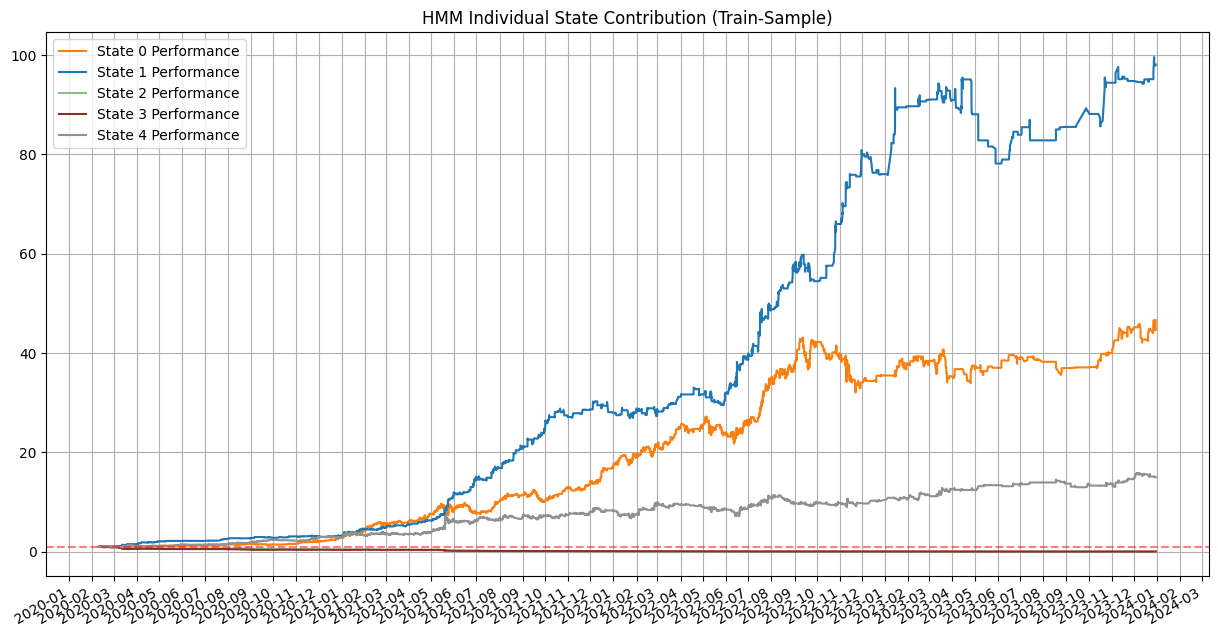

In [11]:
colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(model.n_components):
    df_train_sample = df_train_plot.copy()
    net = df_train_sample['pct'].astype(float).values
    signal = (df_train_sample['state'] == i).astype(float).values
    # 计算策略收益序列
    strat_ret = net * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = net[0]
    
    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_train_sample.index[1] - df_train_sample.index[0] # 计算时间间隔
    plot_dates = [df_train_sample.index[0] - time_delta] + list(df_train_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("HMM Individual State Contribution (Train-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

## 3.2 测试集状态分类

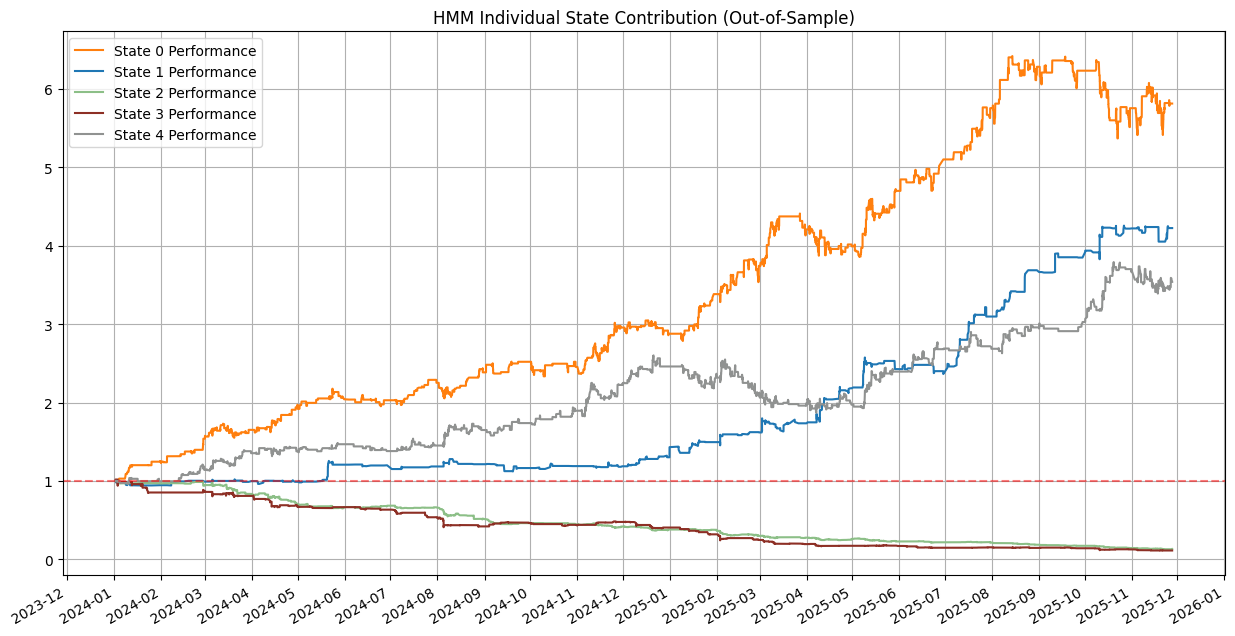

In [12]:
colors = ['#ff7f0e', '#1f77b4', "#8CBF87", "#8D2F25", "#909291", "#4E1945", "#B7B7Eb"]
plt.figure(figsize=(15, 8))
for i in range(model.n_components):
    df_test_sample = df_test_plot.copy()
    # net = df_test_sample['pct'].astype(float).values
    # signal = (df_test_sample['state'] == i).astype(float).values
    # strat_ret = net * signal
    # # 强制第一行跟随市场，确保起跑线逻辑一致
    # strat_ret[0] = net[0]
    
    df_test_sample['signal'] = (df_test_plot['state'] == i).shift(1).fillna(0).astype(float)

    # 计算策略收益序列
    f3_vals = df_test_sample['close_log_ret_1p'].astype(float).values
    signal = df_test_sample['signal'].astype(float).values
    strat_ret = f3_vals * signal
    # 强制第一行跟随市场，确保起跑线逻辑一致
    strat_ret[0] = f3_vals[0]

    # 净值为 1.0 的起点
    # 在所有收益率前面插一个 0
    strategy_cum = np.exp(np.insert(np.cumsum(strat_ret), 0, 0))
    # 插入数据后对应时间也要增加一列
    time_delta = df_test_sample.index[1] - df_test_sample.index[0] # 计算时间间隔
    plot_dates = [df_test_sample.index[0] - time_delta] + list(df_test_sample.index) #增加第一个时间
    plt.plot(plot_dates, strategy_cum, color=colors[i], label=f'State {i} Performance')

plt.axhline(1, color='red', linestyle='--', alpha=0.5) #基准线
plt.title("HMM Individual State Contribution (Out-of-Sample)")
plt.legend()
plt.grid(True)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

## 3.3 收益回测评估

In [13]:
# 计算最大回撤
def calculate_mdd(cum_series):
    """
    计算净值曲线的最大回撤及其结束时间点
    """
    # 转换为 numpy 数组方便计算
    nav = np.array(cum_series)
    # 计算历史滚动最高点
    peaks = np.maximum.accumulate(nav)
    # 计算回撤序列 (当前值 / 历史最高值 - 1)
    drawdowns = (nav - peaks) / peaks
    # 找到最大回撤值（最小值）
    mdd_value = np.min(drawdowns)
    # 找到最大回撤发生的索引位置（即回撤结束/最低点的位置）
    mdd_idx = np.argmin(drawdowns)
    
    return mdd_value, mdd_idx

In [14]:
# 算上换手率
def cal_net_values(post:np.array,ret:np.array) -> np.array:
    '''计算净值序列
    pos: 仓位
    ret:未来1个周期的收益率'''
    fee = 0.001 # 仓位每次变动的磨损
    position_changes = np.hstack((post[0],np.diff(post)))# 拼接初始仓位并记录此时的手续费，后面的时间使用diff的
    ret_array = post*ret - abs(position_changes*fee)
    net_values = 1+(ret_array).cumsum()
    return net_values, ret_array  # 返回净值序列、收益率序列

In [15]:
# 夏普计算
def calculate_sharpe(strat_ret, rf=0, periods=252):
    '''
    strat_ret: 策略收益率序列
    rf: 无风险利率 (年化)（市场的年化收益率）
    periods: 年度交易周期数 
    '''
    # 计算超额收益 (Daily Excess Return)
    excess_ret = strat_ret - (rf / periods)
    
    # 计算均值和标准差
    mean_ret = np.mean(excess_ret)
    std_ret = np.std(excess_ret)
    
    # 计算原始夏普 (非年化)
    if std_ret == 0:
        return 0
    sharpe = mean_ret / std_ret
    
    # 年化处理
    annual_sharpe = sharpe * np.sqrt(periods)
    
    return annual_sharpe


In [16]:
df_train_plot

,Unnamed: 0,open,high,low,close,vol,amount,trade_count,SetDay,time_start,...,146,147,fut_vwap,vol_log_ret_1p,vol_log_ret_5p,close_log_ret_1p,close_log_ret_5p,intraday_range_log,pct,state
DateTime,,,,,,,,,,,,,,,,,,,,,
2020-02-10 05:58:00,345,222.79,225.00,220.12,225.00,85595.274,1.903667e+07,10440.0,2020-02-10,345,...,0.879568,-2.265027,225.380003,0.870769,-0.721776,0.010050,-0.000711,0.021928,-0.030157,3
2020-02-10 06:23:00,346,225.00,226.20,219.82,219.85,184736.265,4.125966e+07,26451.0,2020-02-10,346,...,0.901847,-2.249848,218.583161,0.769299,2.133803,-0.023155,-0.026881,0.028611,0.010200,3
2020-02-10 09:23:00,347,219.85,220.41,217.32,220.40,74107.345,1.621744e+07,10383.0,2020-02-10,347,...,0.917689,-2.235612,220.812754,-0.913415,-1.179660,0.002499,-0.020167,0.014119,0.001147,3
2020-02-10 09:47:00,348,220.40,221.30,217.84,220.95,141740.503,3.114035e+07,19177.0,2020-02-10,348,...,0.927374,-2.222354,221.066121,0.648483,0.903484,0.002492,-0.020960,0.015758,-0.004879,3
2020-02-10 13:04:00,349,220.93,221.37,219.77,220.07,35963.077,7.931796e+06,4730.0,2020-02-10,349,...,0.931198,-2.210099,219.987469,-1.371505,0.003632,-0.003991,-0.012104,0.007254,0.013759,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 02:00:00,17586,2335.75,2388.74,2326.19,2343.77,1560149.899,3.678567e+09,1409996.0,2023-12-29,17586,...,-0.850253,-1.393521,2341.715577,2.258464,2.575798,0.003432,-0.021856,0.026534,-0.013899,0
2023-12-29 15:42:00,17587,2343.78,2344.99,2289.82,2307.64,749128.820,1.735711e+09,597120.0,2023-12-29,17587,...,-0.859855,-1.410501,2309.167719,-0.733626,0.419256,-0.015535,-0.026188,0.023808,-0.018181,2
2023-12-29 17:18:00,17588,2307.64,2321.59,2254.72,2267.97,750504.209,1.724501e+09,668309.0,2023-12-29,17588,...,-0.862576,-1.424560,2267.185574,0.001834,0.475100,-0.017340,-0.043410,0.029226,0.005353,2


1
【市场基准】最大回撤: -90.22% | 发生时间: 2020-03-13 02:13:00
【HMM策略】最大回撤: -37.95% | 发生时间: 2020-03-13 01:37:00


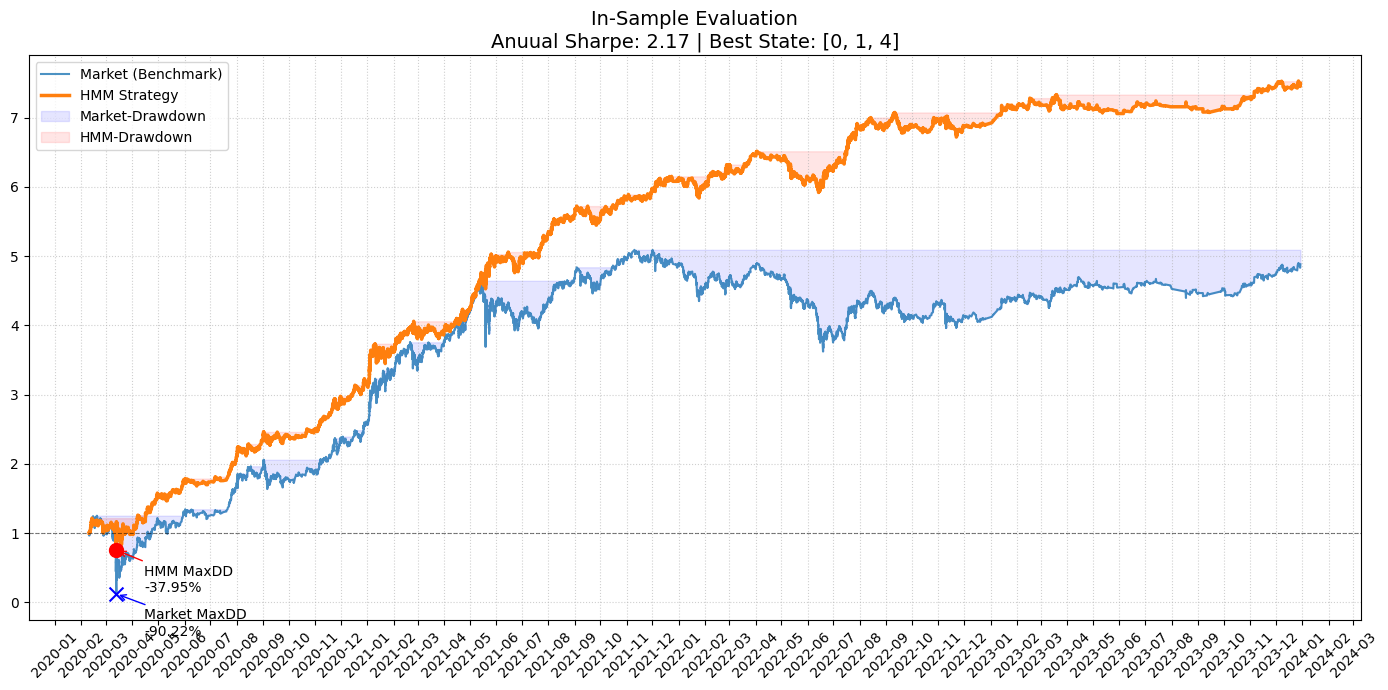

【市场基准】最大回撤: nan% | 发生时间: 2025-11-27 15:22:00
【HMM策略】最大回撤: nan% | 发生时间: 2025-11-27 15:22:00


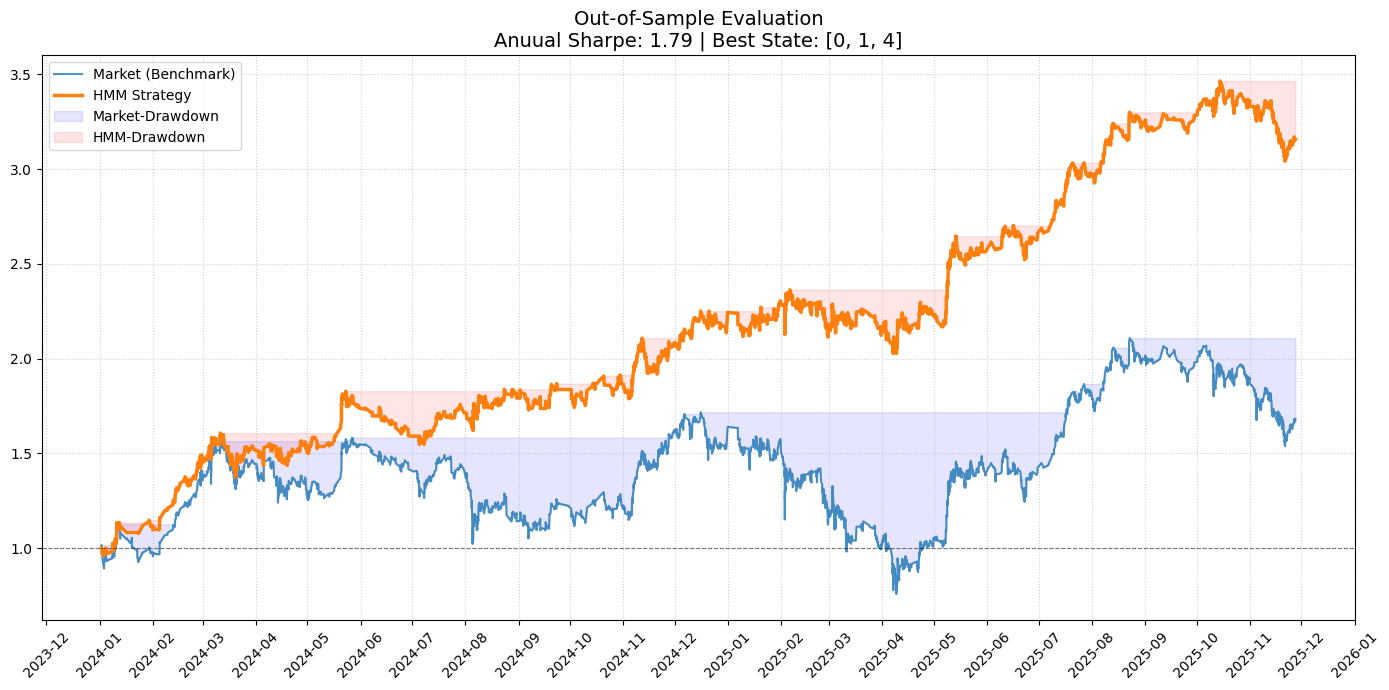

In [17]:
def plot_backtest(df_input, title, use_state):
    # 1. 深拷贝并预处理，确保无警告
    df = df_input.copy()
    df.index = pd.to_datetime(df.index)
    
    # T时刻的仓位取T+1时刻的收益率
    # 对不同状态取不同仓位
    pos_market = np.ones_like(df['state'].values)
    pos_array = df['state'].isin(use_state).astype(float).values # state
    
    # 计算策略收益序列
    res_values = df['pct'].astype(float).values

    net_values, net_ret_array = cal_net_values(pos_array, res_values)
    market_values, market_ret_array = cal_net_values(pos_market, res_values)
    
    df['net_ret_array'] = net_ret_array
    net_ret_date = df['net_ret_array'].groupby(df.index.date).apply(lambda x: np.prod(1 + x) - 1) # 复利计算收益率

    plot_dates = list(df.index)

    m_mdd_val, m_mdd_idx = calculate_mdd(market_values)
    s_mdd_val, s_mdd_idx = calculate_mdd(net_values)

    # 获取对应的日期（从 plot_dates 中提取）
    m_mdd_date = plot_dates[m_mdd_idx]
    s_mdd_date = plot_dates[s_mdd_idx]

    annual_sharpe = calculate_sharpe(net_ret_date)

    print(f"【市场基准】最大回撤: {m_mdd_val:.2%} | 发生时间: {m_mdd_date}")
    print(f"【HMM策略】最大回撤: {s_mdd_val:.2%} | 发生时间: {s_mdd_date}")

    plt.figure(figsize=(14, 7), dpi=100)
    
    # 使用你指定的蓝色和橙色
    plt.plot(plot_dates, market_values, color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
    plt.plot(plot_dates, net_values, color='#ff7f0e', label='HMM Strategy', linewidth=2.5)
    
    # 绘制最大回撤区域（可选，更专业）
    market_peak = np.maximum.accumulate(market_values)
    strategy_peak = np.maximum.accumulate(net_values)
    plt.fill_between(plot_dates, market_values, market_peak, color='blue', alpha=0.1, label='Market-Drawdown')
    plt.fill_between(plot_dates, net_values, strategy_peak, color='red', alpha=0.1, label='HMM-Drawdown')

    # 起始点辅助线
    plt.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # 标题与统计信息
    plt.title(f"{title}\nAnuual Sharpe: {annual_sharpe:.2f} | Best State: {use_state}", fontsize=14)
    
    # 坐标轴优化
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.scatter(m_mdd_date, market_values[m_mdd_idx], color='blue', s=100, marker='x', 
            label=f'Market MaxDD: {m_mdd_val:.2%}', zorder=5)

    # 标记策略最大回撤点
    plt.scatter(s_mdd_date, net_values[s_mdd_idx], color='red', s=100, marker='o', 
                label=f'HMM MaxDD: {s_mdd_val:.2%}', zorder=5)
    plt.annotate(f'Market MaxDD\n{m_mdd_val:.2%}', 
                xy=(m_mdd_date, market_values[m_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='blue'))
    plt.annotate(f'HMM MaxDD\n{s_mdd_val:.2%}', 
                xy=(s_mdd_date, net_values[s_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red'))
    plt.show()
# 状态总数
states = model.n_components
# 训练集确定best_state
best_state = df_train_plot.groupby('state')['close_log_ret_1p'].mean().idxmax()
print(best_state)
buy_state = [0,1,4]
plot_backtest(df_train_plot, "In-Sample Evaluation", buy_state)
plot_backtest(df_test_plot, "Out-of-Sample Evaluation", buy_state)

【市场基准】最大回撤: -90.22% | 发生时间: 2020-03-13 02:13:00
【HMM策略】最大回撤: -31.87% | 发生时间: 2020-03-19 00:52:00


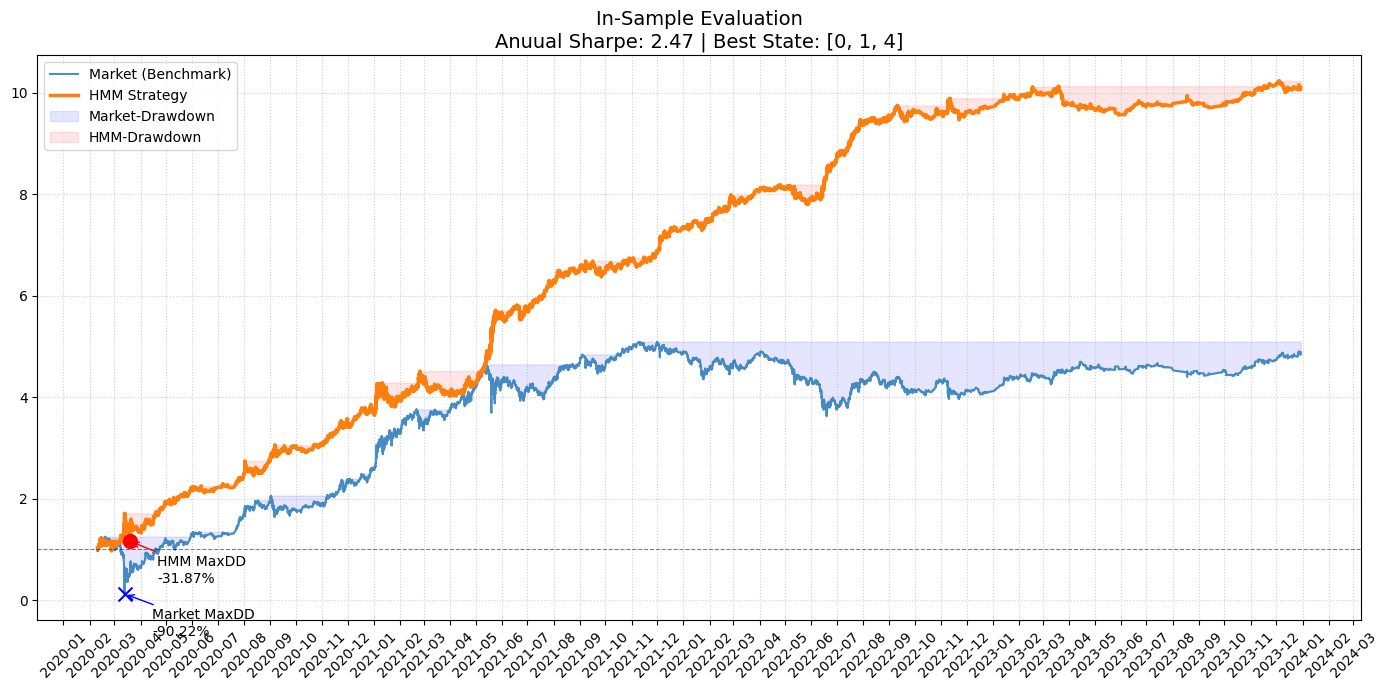

【市场基准】最大回撤: nan% | 发生时间: 2025-11-27 15:22:00
【HMM策略】最大回撤: nan% | 发生时间: 2025-11-27 15:22:00


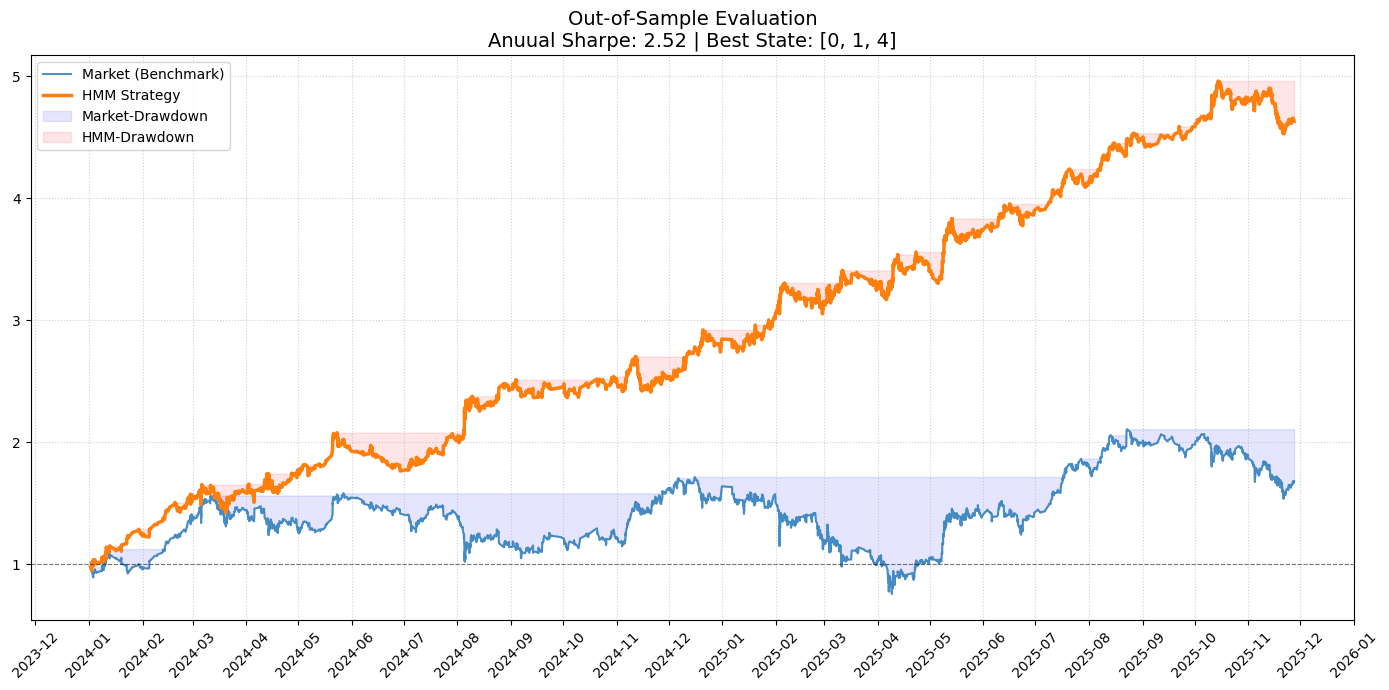

In [18]:
def plot_backtest(df_input, title, use_state):
    # 1. 深拷贝并预处理，确保无警告
    df = df_input.copy()
    df.index = pd.to_datetime(df.index)
    
    # T时刻的仓位取T+1时刻的收益率
    # 对不同状态取不同仓位
    pos_market = np.ones_like(df['state'].values)
    pos_map = {4: 1, 3: -1, 2: -1, 1: 1, 0: 1}
    df['pos'] = df['state'].map(pos_map)
    pos_array = df['pos'].values
    
    # 计算策略收益序列
    res_values = df['pct'].astype(float).values

    net_values, net_ret_array = cal_net_values(pos_array, res_values)
    market_values, market_ret_array = cal_net_values(pos_market, res_values)
    df['net_ret_array'] = net_ret_array
    net_ret_date = df['net_ret_array'].groupby(df.index.date).apply(lambda x: np.prod(1 + x) - 1) # 复利计算收益率


    plot_dates = list(df.index)

    m_mdd_val, m_mdd_idx = calculate_mdd(market_values)
    s_mdd_val, s_mdd_idx = calculate_mdd(net_values)

    # 获取对应的日期（从 plot_dates 中提取）
    m_mdd_date = plot_dates[m_mdd_idx]
    s_mdd_date = plot_dates[s_mdd_idx]

    annual_sharpe = calculate_sharpe(net_ret_date)

    print(f"【市场基准】最大回撤: {m_mdd_val:.2%} | 发生时间: {m_mdd_date}")
    print(f"【HMM策略】最大回撤: {s_mdd_val:.2%} | 发生时间: {s_mdd_date}")

    plt.figure(figsize=(14, 7), dpi=100)
    
    # 使用你指定的蓝色和橙色
    plt.plot(plot_dates, market_values, color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
    plt.plot(plot_dates, net_values, color='#ff7f0e', label='HMM Strategy', linewidth=2.5)
    
    # 绘制最大回撤区域（可选，更专业）
    market_peak = np.maximum.accumulate(market_values)
    strategy_peak = np.maximum.accumulate(net_values)
    plt.fill_between(plot_dates, market_values, market_peak, color='blue', alpha=0.1, label='Market-Drawdown')
    plt.fill_between(plot_dates, net_values, strategy_peak, color='red', alpha=0.1, label='HMM-Drawdown')

    # 起始点辅助线
    plt.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    # 标题与统计信息
    plt.title(f"{title}\nAnuual Sharpe: {annual_sharpe:.2f} | Best State: {use_state}", fontsize=14)
    
    # 坐标轴优化
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.xticks(rotation=45)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left')
    
    plt.tight_layout()
    plt.scatter(m_mdd_date, market_values[m_mdd_idx], color='blue', s=100, marker='x', 
            label=f'Market MaxDD: {m_mdd_val:.2%}', zorder=5)

    # 标记策略最大回撤点
    plt.scatter(s_mdd_date, net_values[s_mdd_idx], color='red', s=100, marker='o', 
                label=f'HMM MaxDD: {s_mdd_val:.2%}', zorder=5)
    plt.annotate(f'Market MaxDD\n{m_mdd_val:.2%}', 
                xy=(m_mdd_date, market_values[m_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='blue'))
    plt.annotate(f'HMM MaxDD\n{s_mdd_val:.2%}', 
                xy=(s_mdd_date, net_values[s_mdd_idx]), 
                xytext=(20, -30), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='red'))
    plt.show()
# 状态总数
states = model.n_components
# 训练集确定best_state
# best_state = df_train_plot.groupby('state')['f3'].mean().idxmax()
buy_state = [0,1,4]
plot_backtest(df_train_plot, "In-Sample Evaluation", buy_state)
plot_backtest(df_test_plot, "Out-of-Sample Evaluation", buy_state)

## 3.5 保存数据

In [19]:
df_test = df_test_plot.copy()
df_test.index = pd.to_datetime(df_test.index)

# T时刻的仓位取T+1时刻的收益率
# 对不同状态取不同仓位
pos_market = np.ones_like(df_test['state'].values)
pos_map = {3: 1.0, 2: -1.0, 1: 1, 0: -1}
df_test['pos'] = df_test['state'].map(pos_map)
pos_array = df_test['pos'].values
# 计算策略收益序列
res_values = df_test['pct'].astype(float).values
print("res:", res_values)
net_values, _ = cal_net_values(pos_array, res_values)
market_values, _ = cal_net_values(pos_market, res_values)
df_test["HMM-net"] = net_values
df_test["market-net"] = market_values
df_test.to_csv("../data/HMM_model_symb.csv")



res: [ 0.01626147  0.00045681 -0.02289531 ...  0.00222689  0.01310222
         nan]
